# Sprint 5 - Análisis Exploratorio Descriptivo (Sesiones)

En el presente caso de estudio se busca integrar y aplicar los conocimientos desarrollados previamente en programación, manipulación de datos y visualización, orientándolos hacia la construcción de uno de los procesos fundamentales dentro dell trabajo que un analista realiza: el **Análisis Exploratorio de Datos** (comúnmente conocido como EDA por sus siglas en inglés). Este tipo de análisis constituye una de las primeras etapas dentro de cualquier proyecto, ya que permite comprender en profundidad la naturaleza de la información para a partir de este entendimiento tomar decisiones estratégicas.

El propósito principal del **EDA** es examinar, resumir e interpretar la información disponible con el fin de identificar patrones, tendencias, anomalías, relaciones entre variables y posibles problemas de calidad en los datos. Más allá de simplemente observar tablas o calcular métricas básicas, el **EDA** busca generar una comprensión integral del comportamiento de las variables y de los fenómenos representados en el conjunto de datos. Esta etapa resulta esencial para formular hipótesis, detectar inconsistencias, definir estrategias y orientar adecuadamente la toma de decisiones basada en información.

En el contexto profesional, este análisis representa una habilidad indispensable para cualquier científico o analista de datos, ya que una comprensión insuficiente de los datos puede conducir a interpretaciones incorrectas, conclusiones erróneas o modelos poco confiables. Por esta razón, el **EDA** no debe entenderse únicamente como una etapa técnica, sino también como un proceso analítico e investigativo que combina herramientas estadísticas, pensamiento crítico y capacidad de interpretación.

Para desarrollar este tipo de análisis, tradicionalmente se emplean tres grandes herramientas complementarias que aportan mecanismos distintos para explorar y comprender la información desde diferentes perspectivas:

* **Estadística descriptiva**: corresponde al conjunto de técnicas orientadas al resumen y representación de datos mediante medidas estadísticas, con el objetivo es describir las características principales de una variable o conjunto de variables. Estas herramientas permiten por tanto obtener una visión inicial del comportamiento general de los datos y constituyen el punto de partida de cualquier **EDA**.
* **Visualización de datos**: representa una de las herramientas más poderosas dentro del análisis exploratorio, ya que permite interpretar información compleja de manera intuitiva mediante gráficos y representaciones visuales equivalentes, haciendo posible identificar tendencias, valores atípicos, agrupamientos y relaciones que muchas veces no son evidentes únicamente con estadísticas numéricas. En consecuencia, la visualización complementa y fortalece a las demás herramientas, facilitando además la comunicación efectiva de hallazgos.
* **Estadística inferencial**: corresponde al área de la estadística enfocada en la formulación y validación de hipótesis a partir de la información disponible. A diferencia de la estadística descriptiva, que únicamente resume datos observados, la inferencia estadística busca extraer conclusiones más generales sobre estos datos, así como las relaciones y comportamientos subyacentes. Dentro de un **EDA**, este tipo de herramientas puede ayudar a evaluar asociaciones entre variables, diferencias entre grupos existentes y posibles patrones estadísticamente relevantes en el contexto.

Durante el desarrollo de este caso de estudio, nos concentraremos en los dos primeros puntos antes descritos, aplicando estos conocimientos con la librería **Tidyverse**. Con esto, seremos capaces de construir un flujo básico de trabajo analítico similar al utilizado en proyectos reales de ciencia de datos y analítica de negocios, permitiéndote desarrollar no solamente habilidades técnicas relacionadas con programación y estadística aplicada, sino también capacidades analíticas fundamentales para interpretar información, formular preguntas relevantes y generar conocimiento útil a partir de los datos disponibles.

## Entendimiento del contexto

El Banco Mundial es un organismo multinacional cuyo propósito es el brindar asistencia económica y financiera a sus estados asociados. Entre los servicios que ofrece se encuentra la de generar y publicar diversos indicadores macroeconómicos, sociales, demográficos y ambientales que permiten estudiar y contrastar la situación multidimensional entre países a través de los años. Si es de tu interés, puedes acceder a todo su catálogo de información en este [repositorio](https://data.worldbank.org/).

Un dato importante para que tengas en cuenta es que a nivel mundial se reconocen oficialmente poco más de 200 estados, de los cuales algunos proveen de información al Banco Mundial (estados miembro de la entidad) y otros no lo hacen. La entidad, si le es posible, estima mediante modelos econométricos algunos de estos indicadores faltantes, aunque en muchos casos ha preferido dejar en blanco estos datos a fin de garantizar la integridad original de la información.

En este sentido, el Banco Mundial te ha contratado para que realices un análisis respecto al comportamiento de la variación del Producto Interno Bruto (PIB) entre los años 2000 y 2023. En concreto, esta entidad quiere que le asistas contestando las siguientes preguntas:

* ¿Cuál ha sido el comportamiento de este indicador en todo el período estudiado?
* ¿Qué variables inciden principalmente en los cambios a nivel de este indicador?
* ¿Qué tan probable es que un país tenga una recesión (reducción del PIB) en un año cualquiera?
* ¿Existen diferencias significativas en el crecimiento de países de "bajo desarrollo" frente a países de "alto desarrollo"?

## Entendimiento de los datos

Como punto de partida, vale que importes las librerías que vas a utilizar.

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Carga ahora los datos de los archivos [**cat_codpais3.csv**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_analytics/refs/heads/main/datasets/cat_codpais3.csv), [**wb_ahorro.csv**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_analytics/refs/heads/main/datasets/wb_ahorro.csv), [**wb_crecimpib.csv**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_analytics/refs/heads/main/datasets/wb_crecimpib.csv), [**wb_crecimpob.csv**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_analytics/refs/heads/main/datasets/wb_crecimpob.csv) y [**wb_poburbana.csv**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_analytics/refs/heads/main/datasets/wb_poburbana.csv). Estos datos son los que te ha compartido el Banco Mundial para que bases tu análisis a partir de allí.

In [2]:
# Cargar catalogo de codificacion de paises
cat_pais <- read_csv("https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_analytics/refs/heads/main/datasets/cat_codpais3.csv")

# Cargar datos de ahorro por pais
df_ahorro <- read_csv("https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_analytics/refs/heads/main/datasets/wb_ahorro.csv")

# Cargar datos de variacion del PIB
df_pib <- read_csv("https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_analytics/refs/heads/main/datasets/wb_crecimpib.csv")

# Cargar datos de variacion de poblacion
df_poblacion <- read_csv("https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_analytics/refs/heads/main/datasets/wb_crecimpob.csv")

# Cargar datos de porcentaje de poblacion urbana
df_urbana <- read_csv("https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_analytics/refs/heads/main/datasets/wb_poburbana.csv")

Rows: 214 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): country_code, country_name

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 265 Columns: 25
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): Country Code
dbl (24): 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 265 Columns: 25
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): Country Code
dbl (24): 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column t

El detalle de estas 5 tablas se explica a continuación:

* **cat_codpais3**: [264 filas, 2 columnas] Catálogo que contiene el nombre del país y sus siglas *Alpha-3* de acuerdo a la normativa ISO.
* **wb_ahorro**: [265, 25] Series anuales 2000 - 2023 por país respecto al porcentaje promedio de ahorro que mantienen los habitantes como porcentaje de su ingreso. 
* **wb_crecimpib**: [265, 25] Series anuales 2000 - 2023 por país respecto a la tasa de variación del PIB. 
* **wb_crecimpob**: [265, 25] Series anuales 2000 - 2023 por país respecto a la tasa de variación de la población.
* **wb_poburbana**: [265, 25] Series anuales 2000 - 2023 por país respecto al porcentaje de la población que reside en áreas urbanas.

A fin de explorar estos datos, crea una función que te permita mirar: 

* La estructura general del dataset.
* Un detalle de valores perdidos.
* Una muestra aleatoria de 5 filas en la que se presenten solamente las primeras 6 columnas del dataset.
* Un conteo de los duplicados existentes.

In [3]:
fun_diagnostico <- function (df) {
    cat("ESTRUCTURA GENERAL DE LA TABLA:\n")
    glimpse(df)
    cat("==============================================================\n")
    cat("VALORES PERDIDOS:\n")
    print(colSums(is.na(df)))
    cat("==============================================================\n")
    cat("MUESTRA DE LOS DATOS:\n")
    muestra <- df[,1:min(c(6, ncol(df)))] %>% sample_n(5)
    print(muestra)
    cat("==============================================================\n")
    print(paste("FILAS DUPLICADAS:", sum(duplicated(df))))
}

Aplica la función creada en cada uno de los datasets del Banco Mundial.

In [4]:
fun_diagnostico(cat_pais)

ESTRUCTURA GENERAL DE LA TABLA:
Rows: 214
Columns: 2
$ country_code <chr> "ABW", "AFG", "AGO", "ALB", "AND", "ARE", "ARG", "ARM", "…
$ country_name <chr> "Aruba", "Afganistan", "Angola", "Albania", "Andorra", "E…
VALORES PERDIDOS:
country_code country_name 
           0            0 
MUESTRA DE LOS DATOS:
# A tibble: 5 × 2
  country_code country_name           
  <chr>        <chr>                  
1 PER          Peru                   
2 CIV          Cote d Ivoire          
3 MKD          Macedonia del Norte    
4 MMR          Myanmar                
5 VIR          Islas Virgenes (EE.UU.)
[1] "FILAS DUPLICADAS: 0"


In [5]:
fun_diagnostico(df_ahorro)

ESTRUCTURA GENERAL DE LA TABLA:
Rows: 265
Columns: 25
$ `Country Code` <chr> "ABW", "AFE", "AFG", "AFW", "AGO", "ALB", "AND", "ARB",…
$ `2000`         <dbl> 23.7146427, NA, NA, NA, NA, 25.8913492, NA, NA, NA, 14.…
$ `2001`         <dbl> 19.189309, NA, NA, NA, NA, 28.925219, NA, NA, NA, 14.21…
$ `2002`         <dbl> 12.207159, 20.668760, NA, NA, 28.876816, 25.516717, NA,…
$ `2003`         <dbl> 14.646462, 20.794876, NA, NA, 26.055461, 26.258269, NA,…
$ `2004`         <dbl> 17.248334, 22.488142, NA, NA, 33.536006, 29.384837, NA,…
$ `2005`         <dbl> -1.652954, 23.097135, NA, NA, 41.187653, 30.106495, NA,…
$ `2006`         <dbl> 13.104232, 23.990366, NA, NA, 43.454584, 29.068943, NA,…
$ `2007`         <dbl> 2.917364, 23.820055, NA, NA, 41.498970, 23.954293, NA, …
$ `2008`         <dbl> 15.345106, 22.353574, NA, NA, 38.658859, 17.730924, NA,…
$ `2009`         <dbl> 11.174913, 18.469142, NA, NA, 27.657874, 17.335897, NA,…
$ `2010`         <dbl> 4.648619, 20.879925, NA, NA, 36.987339, 19.

In [6]:
fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
Rows: 265
Columns: 25
$ `Country Code` <chr> "ABW", "AFE", "AFG", "AFW", "AGO", "ALB", "AND", "ARB",…
$ `2000`         <dbl> 7.6229206, 3.2198030, NA, 3.8597603, 3.0546242, 6.94621…
$ `2001`         <dbl> 4.182002, 3.510147, -9.431974, 5.209094, 4.205999, 8.29…
$ `2002`         <dbl> -0.9449535, 3.8416464, 28.6000012, 9.9274271, 13.665688…
$ `2003`         <dbl> 1.1105046, 2.9634052, 8.8322778, 5.5329666, 2.9900000, …
$ `2004`         <dbl> 7.2937281, 5.5573635, 1.4141180, 7.9926986, 10.9500000,…
$ `2005`         <dbl> -0.3831377, 6.1648359, 11.2297148, 5.8289400, 15.030000…
$ `2006`         <dbl> 1.127411, 6.577594, 5.357403, 5.374762, 11.550000, 5.90…
$ `2007`         <dbl> 3.089544, 6.646593, 13.826320, 5.522719, 14.010000, 5.9…
$ `2008`         <dbl> 1.83575517, 4.37109757, 3.92498382, 6.28146531, 11.1699…
$ `2009`         <dbl> -11.6777414, 0.8803314, 21.3905284, 6.2821024, 0.860000…
$ `2010`         <dbl> -2.7334568, 5.2337780, 14.3624415, 6.970600

In [7]:
fun_diagnostico(df_poblacion)

ESTRUCTURA GENERAL DE LA TABLA:
Rows: 265
Columns: 25
$ `Country Code` <chr> "ABW", "AFE", "AFG", "AFW", "AGO", "ALB", "AND", "ARB",…
$ `2000`         <dbl> 2.5392344, 2.5835792, 1.4438030, 2.7495997, 3.2441215, …
$ `2001`         <dbl> 1.7687566, 2.5899606, 0.7425168, 2.7996535, 3.2852172, …
$ `2002`         <dbl> 1.19471806, 2.60659803, 6.44932148, 2.81145269, 3.33513…
$ `2003`         <dbl> 0.9973955, 2.6177643, 7.5410190, 2.8164806, 3.4133212, …
$ `2004`         <dbl> 0.9009892, 2.6449684, 3.9331777, 2.8286422, 3.5063888, …
$ `2005`         <dbl> 1.0030772, 2.6662416, 3.5765080, 2.8412112, 3.5576590, …
$ `2006`         <dbl> 1.1815655, 2.7025211, 4.1396780, 2.8327797, 3.5920133, …
$ `2007`         <dbl> 1.2277108, 2.7471089, 1.7931957, 2.8284093, 3.6395893, …
$ `2008`         <dbl> 1.2413974, 2.7658160, 2.0023333, 2.8329162, 3.6709092, …
$ `2009`         <dbl> 1.2332313, 2.7557453, 3.5612884, 2.8440372, 3.6934825, …
$ `2010`         <dbl> 1.1315410, 2.7579291, 2.8949041, 2.8465357,

In [8]:
fun_diagnostico(df_urbana)

ESTRUCTURA GENERAL DE LA TABLA:
Rows: 265
Columns: 25
$ `Country Code` <chr> "ABW", "AFE", "AFG", "AFW", "AGO", "ALB", "AND", "ARB",…
$ `2000`         <dbl> 46.71700, 28.77278, 22.07800, 35.33705, 50.08700, 41.74…
$ `2001`         <dbl> 46.33900, 29.07159, 22.16900, 35.94491, 51.27400, 42.43…
$ `2002`         <dbl> 45.97200, 29.38619, 22.26100, 36.55488, 52.46100, 43.50…
$ `2003`         <dbl> 45.60600, 29.69842, 22.35300, 37.17331, 53.64500, 44.57…
$ `2004`         <dbl> 45.24000, 30.01415, 22.50000, 37.79898, 54.82700, 45.65…
$ `2005`         <dbl> 44.87500, 30.34987, 22.70300, 38.43448, 56.00000, 46.73…
$ `2006`         <dbl> 44.51100, 30.67607, 22.90700, 39.07930, 56.76400, 47.81…
$ `2007`         <dbl> 44.14700, 30.93477, 23.11300, 39.72160, 57.52400, 48.90…
$ `2008`         <dbl> 43.78300, 31.34324, 23.32000, 40.36054, 58.28200, 49.99…
$ `2009`         <dbl> 43.42100, 31.75753, 23.52800, 41.00151, 59.03400, 51.07…
$ `2010`         <dbl> 43.05900, 32.18129, 23.73700, 41.64716, 59.

Hagamos ahora un experimento, filtra los datos de variación del PIB de Estados Unidos (USA) de los años 2013 a 2019. Guarda estos datos en una variable.

In [9]:
pib_usa <- df_pib %>%
filter(`Country Code` == "USA") %>%
select("2013", "2014", "2015", "2016", "2017", "2018", "2019")

print(pib_usa)

# A tibble: 1 × 7
  `2013` `2014` `2015` `2016` `2017` `2018` `2019`
   <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>
1   2.12   2.52   2.95   1.82   2.46   2.97   2.47


Intenta ahora graficar estos datos con `ggplot` como usualmente lo has venido haciendo. Al intentarlo seguramente te darás cuenta que no es posible de una manera sencilla.

En cuanto a estos resultados notemos dos puntos importantes: 

* Por una parte, el filtrado no es tan natural como usualmente lo hacemos. tenemos que utilizar tanto la función `filter` como `select`. 
* Además no es posible graficar de forma directa y sencilla con `ggplot`. 

Esto se explica porque el dataset **df_pib** (y todos los demás con excepción de **cat_pais**) es **ANCHO**. Un dataset ancho es aquel en que cada fila representa a una única entidad (en este caso un país) que no se repite en otras filas. Su utilidad radica en que esta presentación de datos es fácil de interpretar por usuarios "no analíticos", justamente porque se puede acceder a la totalidad información de cada entidad de forma rápida y directa.

Sin embargo, para usuarios "analíticos" como nosotros esta presentación no es adecuada, pues nosotros queremos tablas **LARGAS**. En una tabla larga cada fila representa una observación (o lo que es lo mismo un dato) con sus diferentes variables y particularidades, y facilita en consecuencia la manipulación y visualización de información.

Visto todo esto, define tu plan de acción para preparar estos datos.

**PLAN DE ACCIÓN PARA PREPARACIÓN DE DATOS**

| # | Acción |
| ---- | ---- |
| 1 | Para todas las tablsa, con excpeción de cat_pais, es necesario transformar su presentación para que sean tablas *largas* que permitan su uso analítico. |
| 2 | Una vez hecho esto, los nombres de las columnas deben ajustarse a formato *snake_case*. |
| 3 | Hemos evidenciado que existen valores perdidos en los diferentes datasets, sin embargo dado el contexto puede que estos respondan en a diferentes coyunturas dependiendo del país al cual se corresponden (i.e países sin ningún valor, países con un pequeño número de casos ausentes, etc.). Se debe por tanto tomar una decisión sobre como tratarlos una vez que sea posible filtrar esta información fácilmente. |
| 4 | Una vez realizados estos pasos, conviene unir todos los datasets en una única tabla consolidada. |

## Preparación de datos

Vamos a empezar con **df_pib**. Transforma la presentación ancha de esta tabla a una de tipo *larga* aplicando la función `pivot_longer`.

In [10]:
df_pib <- df_pib %>%
pivot_longer(
    cols = -`Country Code`,
    names_to = "year",
    values_to = "value"
)

fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
Rows: 6,360
Columns: 3
$ `Country Code` <chr> "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "ABW",…
$ year           <chr> "2000", "2001", "2002", "2003", "2004", "2005", "2006",…
$ value          <dbl> 7.6229206, 4.1820016, -0.9449535, 1.1105046, 7.2937281,…
VALORES PERDIDOS:
Country Code         year        value 
           0            0          309 
MUESTRA DE LOS DATOS:
# A tibble: 5 × 3
  `Country Code` year  value
  <chr>          <chr> <dbl>
1 ATG            2005   6.47
2 ZAF            2004   4.55
3 FRO            2023  NA   
4 KHM            2022   5.24
5 TUR            2000   6.93
[1] "FILAS DUPLICADAS: 0"


Ajusta los nombres de las columnas para que estos sigan el formato *snake_case*.

In [11]:
names(df_pib) <- names(df_pib) %>%
tolower() %>%
gsub(" ","_", .)

Ya podemos estudiar los valores perdidos con esta tabla *larga*. Identifica diferentes tipologías de países en función de cuántos valores ausentes tengan.

In [12]:
# Obtener casos perdidos por pais
casos_perdidos <- df_pib %>%
filter(is.na(value)) %>%
count(country_code, name = "casos") %>%
arrange(-casos)

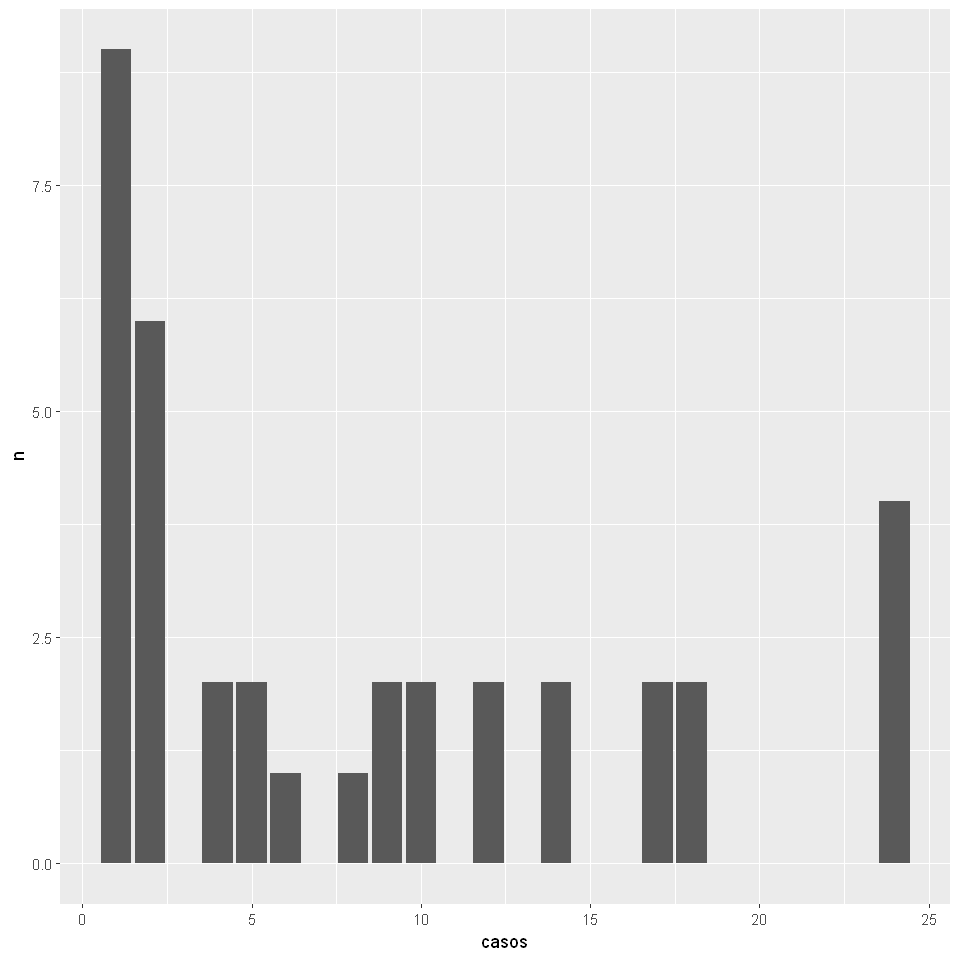

In [13]:
# Contar cuantos paises hay por la cantidad de valores perdidos
casos_por_pais <- casos_perdidos %>%
count(casos)

options(repr.plot.width = 8, repr.plot.height = 8)
ggplot(
    data = casos_por_pais,
    mapping = aes(
        x = casos,
        y = n
    )
) + geom_col()

Podríamos dividir a los países en 2 grupos en base a sus valores ausentes:

* Aquellos que tienen menos de un 20% (aprox. 5) de años sin valores.
* El resto que posee más del 20% de valores perdidos.

Para el último caso que correspondería a los países con pocos o ningún dato relevante, elimina todos estos registros pues su información está limitada pudiendo distorsionar los análisis.

In [14]:
# Extraer casos de paises a eliminar
paises_eliminar <- casos_perdidos %>%
filter(casos > 5) %>%
pull(country_code)

# Eliminar registros de estos paises
df_pib <- df_pib %>%
filter(!country_code %in% paises_eliminar)

Para el primer caso, en donde existen muchos datos relevantes, aplica una imputación por el valor mediano de dicho país considerando que esto no alterará significativamente los resultados de los análisis.

In [15]:
# Incluir de forma temporal la mediana de cada pais
df_pib <- df_pib %>%
group_by(country_code) %>%
mutate(med = median(value, na.rm = TRUE)) %>%
ungroup()

In [16]:
# Imputar la mediana en los casos perdidos correspondientes
df_pib <- df_pib %>%
mutate(value = if_else(
    is.na(value),
    med,
    value
))

In [17]:
# Quitar columna de mediana 
df_pib <- df_pib %>%
select(-med)

fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
Rows: 5,928
Columns: 3
$ country_code <chr> "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "…
$ year         <chr> "2000", "2001", "2002", "2003", "2004", "2005", "2006", "…
$ value        <dbl> 7.6229206, 4.1820016, -0.9449535, 1.1105046, 7.2937281, -…
VALORES PERDIDOS:
country_code         year        value 
           0            0            0 
MUESTRA DE LOS DATOS:
# A tibble: 5 × 3
  country_code year  value
  <chr>        <chr> <dbl>
1 HKG          2002   1.66
2 KEN          2023   5.43
3 EST          2004   6.80
4 GNQ          2005  16.7 
5 EMU          2018   1.79
[1] "FILAS DUPLICADAS: 0"


Concluye ejecutando los siguientes procedimientos de limpieza adicionales:

* Cambiar el tipo de variable de year a entero.
* Cambia el nombre de la columna value a algo más coherente con el contexto como *var_pib*.

In [18]:
# Cambiar el tipo de variable de year
df_pib <- df_pib %>%
mutate(year = as.integer(year))

# Renombrar la columna value
names(df_pib) <- c(names(df_pib)[-3], "var_pib")

fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
Rows: 5,928
Columns: 3
$ country_code <chr> "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "…
$ year         <int> 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 200…
$ var_pib      <dbl> 7.6229206, 4.1820016, -0.9449535, 1.1105046, 7.2937281, -…
VALORES PERDIDOS:
country_code         year      var_pib 
           0            0            0 
MUESTRA DE LOS DATOS:
# A tibble: 5 × 3
  country_code  year var_pib
  <chr>        <int>   <dbl>
1 TUV           2007    7.14
2 MYS           2009   -1.51
3 LVA           2006   12.0 
4 PSE           2005   11.3 
5 GUY           2021   20.0 
[1] "FILAS DUPLICADAS: 0"


Ahora bien, considera que este procedimiento debe repetirse exactamente igual en los datasets **df_ahorro**, **df_poblacion** y **df_urbana**. Haslo de forma **EFICIENTE**.

In [19]:
# Crear una funcion que permita automatizar el procedimiento de limpieza
fun_procesamiento <- function (df, nombre_col) {

    # Transformar a tabla larga
    df <- df %>%
    pivot_longer(
        cols = -`Country Code`,
        names_to = "year",
        values_to = "value"
    )

    # Ajustar nombres de columnas a snake_case
    names(df) <- names(df) %>%
    tolower() %>%
    gsub(" ","_", .)
    
    # Suprimir  o imputar casos perdidos
    paises_eliminar <- df %>%
    filter(is.na(value)) %>%
    count(country_code, name = "casos") %>%
    filter(casos > 5) %>%
    pull(country_code)

    df <- df %>%
    filter(!country_code %in% paises_eliminar)

    df <- df %>%
    group_by(country_code) %>%
    mutate(med = median(value, na.rm = TRUE)) %>%
    ungroup() %>%
    mutate(value = if_else(
        is.na(value),
        med,
        value
    )) %>%
    select(-med)

    # Realizar ajustes finales
    df <- df %>%
    mutate(year = as.integer(year))

    names(df) <- c(names(df)[-3], nombre_col)

    return(df)

}

In [20]:
# Aplicar funcion en df_ahorro
df_ahorro <- fun_procesamiento(df_ahorro, "ahorro")
fun_diagnostico(df_ahorro)

ESTRUCTURA GENERAL DE LA TABLA:
Rows: 3,936
Columns: 3
$ country_code <chr> "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "…
$ year         <int> 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 200…
$ ahorro       <dbl> 23.714643, 19.189309, 12.207159, 14.646462, 17.248334, -1…
VALORES PERDIDOS:
country_code         year       ahorro 
           0            0            0 
MUESTRA DE LOS DATOS:
# A tibble: 5 × 3
  country_code  year ahorro
  <chr>        <int>  <dbl>
1 MEX           2006   21.9
2 ISR           2001   23.9
3 TEC           2004   24.8
4 SEN           2009   15.0
5 BRN           2019   53.6
[1] "FILAS DUPLICADAS: 0"


In [21]:
# Aplicar funcion en df_poblacion
df_poblacion <- fun_procesamiento(df_poblacion, "var_pob")
fun_diagnostico(df_poblacion)

ESTRUCTURA GENERAL DE LA TABLA:
Rows: 6,336
Columns: 3
$ country_code <chr> "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "…
$ year         <int> 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 200…
$ var_pob      <dbl> 2.53923444, 1.76875662, 1.19471806, 0.99739555, 0.9009892…
VALORES PERDIDOS:
country_code         year      var_pob 
           0            0            0 
MUESTRA DE LOS DATOS:
# A tibble: 5 × 3
  country_code  year var_pob
  <chr>        <int>   <dbl>
1 NIC           2013   1.46 
2 SSA           2021   2.59 
3 MEX           2003   1.49 
4 BLR           2021  -0.828
5 MDG           2001   3.00 
[1] "FILAS DUPLICADAS: 0"


In [22]:
# Aplicar funcion en df_urbana
df_urbana <- fun_procesamiento(df_urbana, "pct_urbana")
fun_diagnostico(df_urbana)

ESTRUCTURA GENERAL DE LA TABLA:
Rows: 6,288
Columns: 3
$ country_code <chr> "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "…
$ year         <int> 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 200…
$ pct_urbana   <dbl> 46.71700, 46.33900, 45.97200, 45.60600, 45.24000, 44.8750…
VALORES PERDIDOS:
country_code         year   pct_urbana 
           0            0            0 
MUESTRA DE LOS DATOS:
# A tibble: 5 × 3
  country_code  year pct_urbana
  <chr>        <int>      <dbl>
1 LVA           2007       67.9
2 COG           2007       61.9
3 CZE           2003       73.7
4 ARG           2004       89.9
5 HIC           2001       76.1
[1] "FILAS DUPLICADAS: 0"


Consolida la información de estos 4 datasets en una sola tabla de tal forma que se garantice que no existan nuevos valores ausentes.

In [23]:
df_consolidado <- df_pib %>%
inner_join(
    df_ahorro,
    by = c("country_code", "year")
) %>%
inner_join(
    df_poblacion,
    by = c("country_code", "year")
) %>%
inner_join(
    df_urbana,
    by = c("country_code", "year")
)

fun_diagnostico(df_consolidado)

ESTRUCTURA GENERAL DE LA TABLA:
Rows: 3,936
Columns: 6
$ country_code <chr> "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "…
$ year         <int> 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 200…
$ var_pib      <dbl> 7.6229206, 4.1820016, -0.9449535, 1.1105046, 7.2937281, -…
$ ahorro       <dbl> 23.714643, 19.189309, 12.207159, 14.646462, 17.248334, -1…
$ var_pob      <dbl> 2.53923444, 1.76875662, 1.19471806, 0.99739555, 0.9009892…
$ pct_urbana   <dbl> 46.71700, 46.33900, 45.97200, 45.60600, 45.24000, 44.8750…
VALORES PERDIDOS:
country_code         year      var_pib       ahorro      var_pob   pct_urbana 
           0            0            0            0            0            0 
MUESTRA DE LOS DATOS:
# A tibble: 5 × 6
  country_code  year var_pib ahorro var_pob pct_urbana
  <chr>        <int>   <dbl>  <dbl>   <dbl>      <dbl>
1 COG           2019    1.12   37.6   2.36        67.4
2 IBD           2023    4.45   33.5   0.503       58.0
3 ISL           2006    6.32 

Incorpora ahora en esta información el nombre de los paises de forma que se garantice que no existan valores perdidos en la columna country_name.

In [24]:
df_consolidado <- cat_pais %>%
inner_join(
    df_consolidado,
    by = "country_code"
)

fun_diagnostico(df_consolidado)

ESTRUCTURA GENERAL DE LA TABLA:
Rows: 3,144
Columns: 7
$ country_code <chr> "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "ABW", "…
$ country_name <chr> "Aruba", "Aruba", "Aruba", "Aruba", "Aruba", "Aruba", "Ar…
$ year         <int> 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 200…
$ var_pib      <dbl> 7.6229206, 4.1820016, -0.9449535, 1.1105046, 7.2937281, -…
$ ahorro       <dbl> 23.714643, 19.189309, 12.207159, 14.646462, 17.248334, -1…
$ var_pob      <dbl> 2.53923444, 1.76875662, 1.19471806, 0.99739555, 0.9009892…
$ pct_urbana   <dbl> 46.717, 46.339, 45.972, 45.606, 45.240, 44.875, 44.511, 4…
VALORES PERDIDOS:
country_code country_name         year      var_pib       ahorro      var_pob 
           0            0            0            0            0            0 
  pct_urbana 
           0 
MUESTRA DE LOS DATOS:
# A tibble: 5 × 6
  country_code country_name  year var_pib ahorro var_pob
  <chr>        <chr>        <int>   <dbl>  <dbl>   <dbl>
1 GRC          Grecia      

## Análisis de datos

Como ya se mencionó, el **EDA** busca estudiar el comportamiento de indicadores concretos mediante la aplicación de técnicas estadísticas y visualización. En este sentido conviene recordar que la principal métrica de interés en el contexto de este caso es la **variación del pib**, ante la cual se han planteado las siguientes preguntas:

* ¿Cuál ha sido el comportamiento de este indicador en todo el período estudiado?
* ¿Qué variables inciden principalmente en los cambios a nivel de este indicador?
* ¿Qué tan probable es que un país tenga una recesión en un año cualquiera?
* ¿Existen diferencias significativas en el crecimiento de países de "bajo desarrollo" frente a países de "alto desarrollo"?

Respondamos una a una estas preguntas de negocio.

### ¿Cuál ha sido el comportamiento de la variación en el PIB en todo el período estudiado?

Estudia la distribución del indicador mediante un resumen estadístico. Recuerda que la distribución de una variable hace referencia a sus siguientes características fundamentales:

* Su nivel de centralidad.
* Su grado de dispersión o volatilidad.
* La existencia de valores atípicos.
* La existencia de sesgos.  

In [25]:
res_estadistico <- df_consolidado %>%
summarise(
    count = n(),
    min = min(var_pib),
    q1 = quantile(var_pib, 0.25),
    med = median(var_pib),
    mean = mean(var_pib),
    q3 = quantile(var_pib, 0.75),
    max = max(var_pib),
    std = sd(var_pib),
    cv = std / mean
)

round(res_estadistico,2)

count,min,q1,med,mean,q3,max,std,cv
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3144,-58.32,1.59,3.58,3.44,5.62,153.49,5.43,1.58


Utiliza el criterio *3-sigma* para establecer el rango de variación de PIB de un país cualquiera con un 99% de confianza.

In [26]:
lim_inf <- mean(df_consolidado$var_pib) - 3 * sd(df_consolidado$var_pib)
lim_sup <- mean(df_consolidado$var_pib) + 3 * sd(df_consolidado$var_pib)
print(paste(
    "Con un 99% de confianza, un pais cualquier en un año tendrá una variación del pib entre ",
    formatC(lim_inf, format = "f", digits = 1),
    "% y ",
    formatC(lim_sup, format = "f", digits = 1),
    "%.",
    sep = ""
))

[1] "Con un 99% de confianza, un pais cualquier en un año tendrá una variación del pib entre -12.9% y 19.7%."


Complementa este resultado con un diagrama de cajón con bigotes.

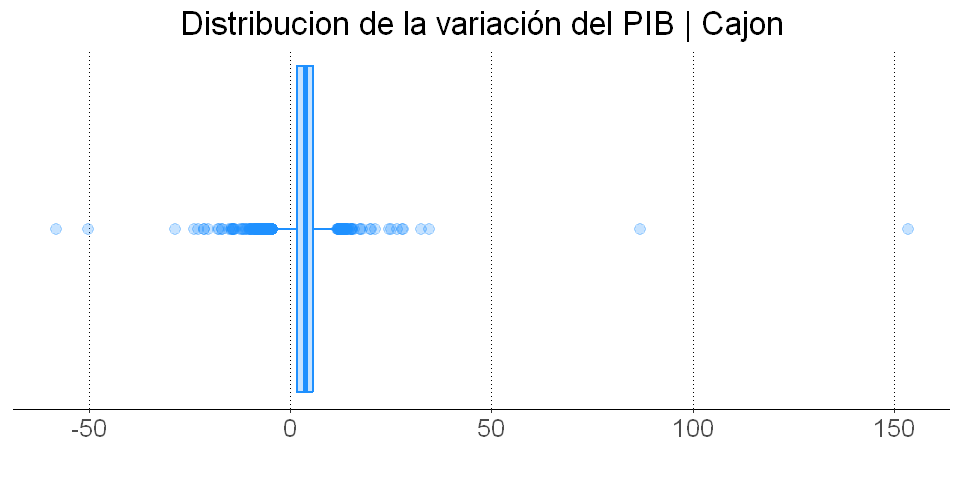

In [27]:
options(repr.plot.width = 8, repr.plot.height = 4)
ggplot(
    data = df_consolidado,
    mapping = aes(
        x = var_pib
    )
) +
geom_boxplot(
    fill = "dodgerblue",
    alpha = 0.25,
    color = "dodgerblue",
    outlier.size = 3,
    linewidth = 0.75
) +
labs(
    title = "Distribucion de la variación del PIB | Cajon",
    x = ""
) +
theme_classic() +
theme(
    panel.grid.major.x = element_line(color = "black", linetype = "dotted"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15),
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    axis.line.y = element_blank()
)

Para una mejor visualización de la distribución, repite el gráfico excluyendo los valores atípicos.

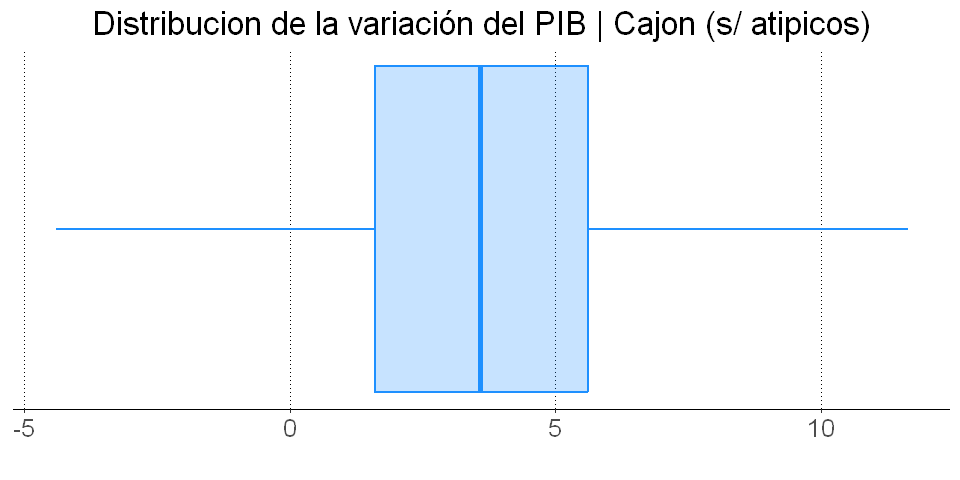

In [28]:
ggplot(
    data = df_consolidado,
    mapping = aes(
        x = var_pib
    )
) +
geom_boxplot(
    fill = "dodgerblue",
    alpha = 0.25,
    color = "dodgerblue",
    linewidth = 0.75,
    outliers = FALSE
) +
labs(
    title = "Distribucion de la variación del PIB | Cajon (s/ atipicos)",
    x = ""
) +
theme_classic() +
theme(
    panel.grid.major.x = element_line(color = "black", linetype = "dotted"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15),
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    axis.line.y = element_blank()
)

Vale señalar que un valor se considera atípico si el mismo NO se encuentra dentro del intervalo 

$$ \left[ Q_1 - 1.5(Q_3-Q_1),\; Q_3 + 1.5(Q_3-Q_1)\right]$$

donde $Q_1$ es el primer cuartil y $Q_3$ el tercero.

Complementa ahora este resultado con un histograma tal que cumplas con lo siguiente: 

* Excluye del dataset los casos atípicos.
* Utiliza un número de columnas ($c$) pertinente para lo cual puedes utilizar la fórmula $c \approx \sqrt{n}$, donde $n$ es el número de observaciones no atípicas.

In [29]:
# Excluir los valores atipicos
umbral_inf <- quantile(df_consolidado$var_pib, 0.25) - 1.5 * (quantile(df_consolidado$var_pib, 0.75) - quantile(df_consolidado$var_pib, 0.25))
umbral_sup <- quantile(df_consolidado$var_pib, 0.75) + 1.5 * (quantile(df_consolidado$var_pib, 0.75) - quantile(df_consolidado$var_pib, 0.25))
df_sin_atipicos <- df_consolidado %>%
filter(var_pib >= umbral_inf & var_pib <= umbral_sup)

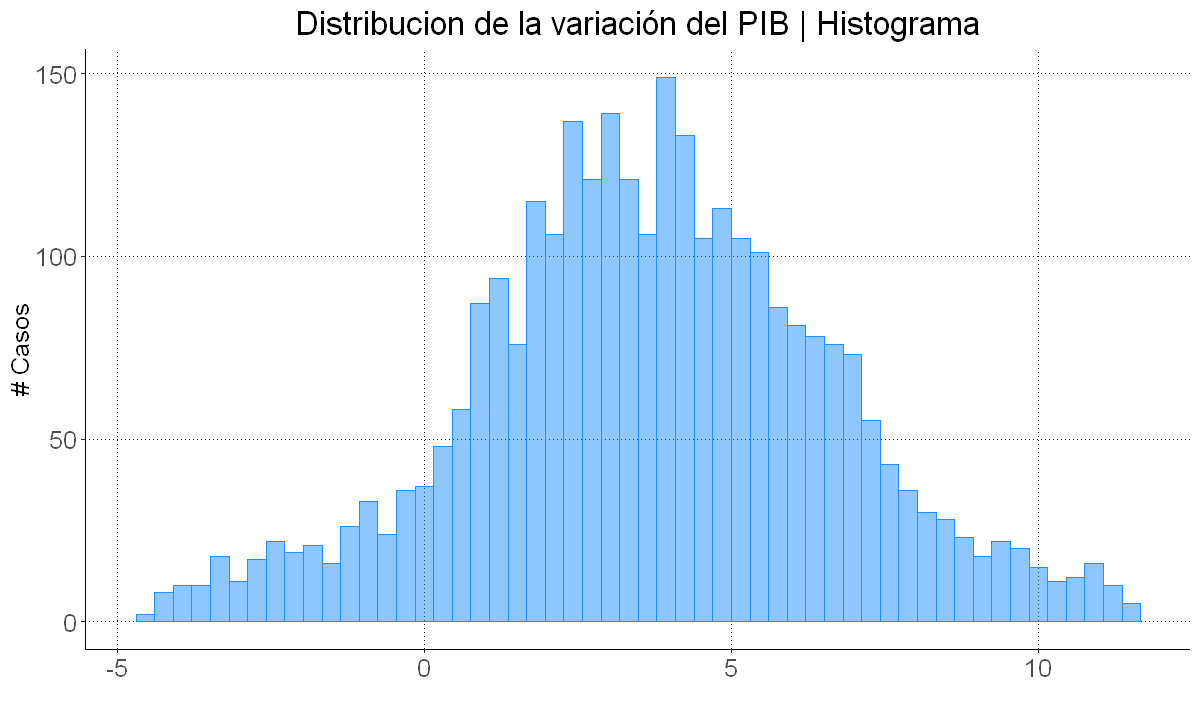

In [30]:
# Generar histograma
options(repr.plot.width = 10, repr.plot.height = 6)
ggplot(
    data = df_sin_atipicos,
    mapping = aes(
        x = var_pib
    )
) +
geom_histogram(
    bins = as.integer(sqrt(nrow(df_sin_atipicos))),
    color = "dodgerblue",
    fill = "dodgerblue",
    alpha = 0.5
) +
labs(
    title = "Distribucion de la variación del PIB | Histograma",
    x = "",
    y = "# Casos"
) +
theme_classic() +
theme(
    panel.grid.major = element_line(color = "black", linetype = "dotted"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15)
)

El histograma puede resumirse en un diagrama de densidad. Créalo.

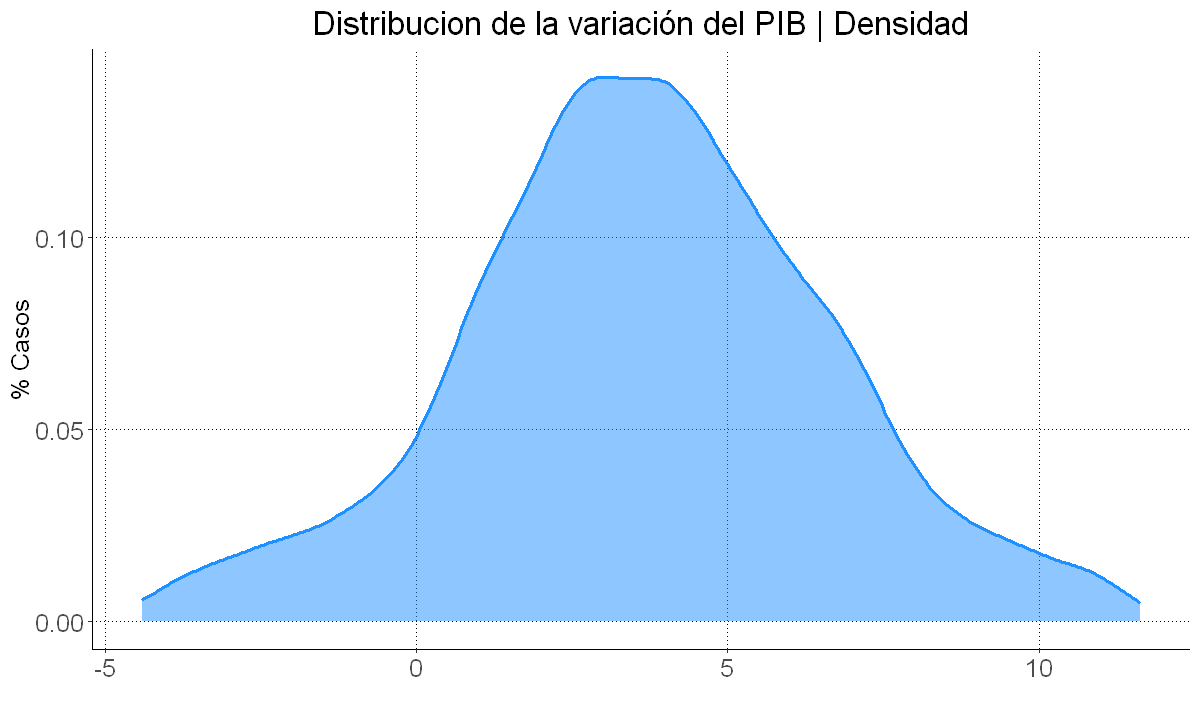

In [31]:
ggplot(
    data = df_sin_atipicos,
    mapping = aes(
        x = var_pib
    )
) +
geom_density(
    color = "dodgerblue",
    linewidth = 1,
    fill = "dodgerblue",
    alpha = 0.5
) +
labs(
    title = "Distribucion de la variación del PIB | Densidad",
    x = "",
    y = "% Casos"
) +
theme_classic() +
theme(
    panel.grid.major = element_line(color = "black", linetype = "dotted"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15)
)

Dado que la variable está definida en el tiempo, genera finalmente un gráfico con la evolución a través de los años de la variación en el PIB promedio mundial.

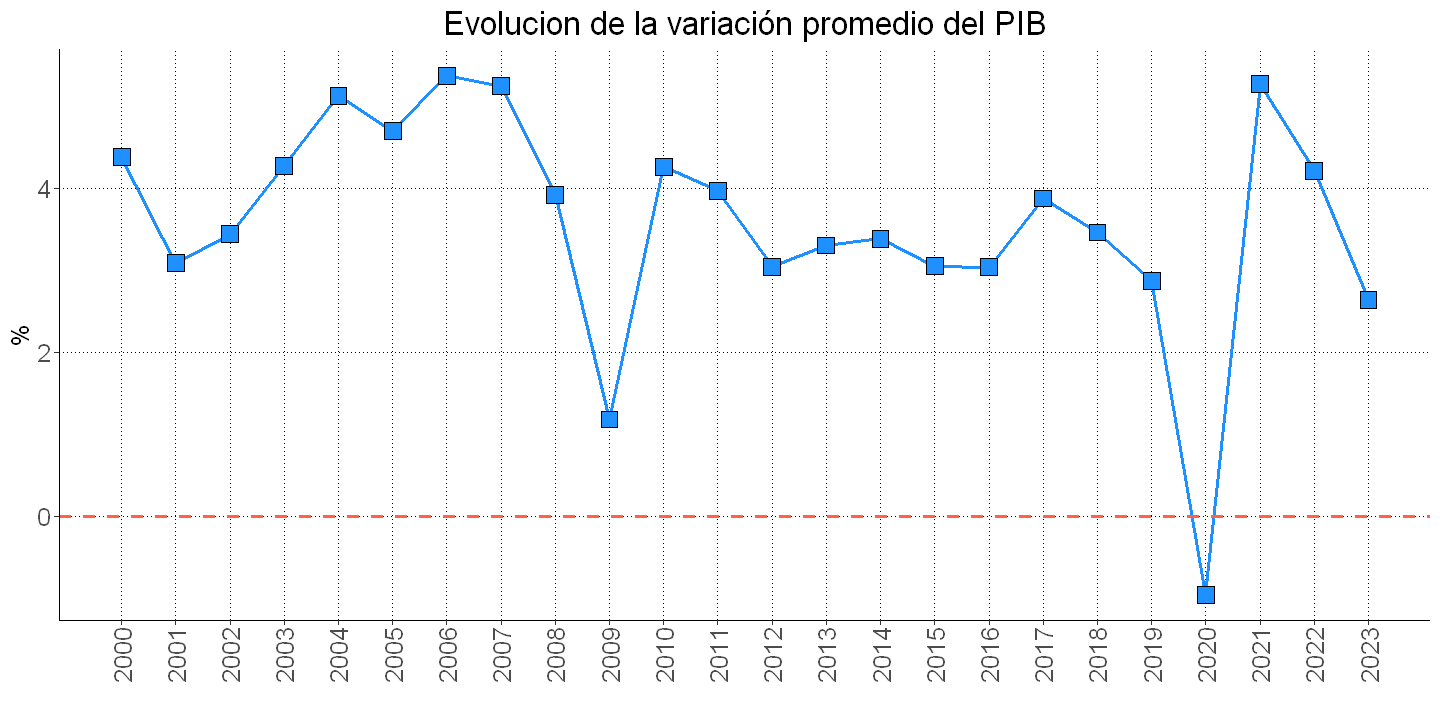

In [32]:
# Agrupar datos
pib_anual <- df_sin_atipicos %>%
group_by(year) %>%
summarise(var_pib = mean(var_pib)) %>%
ungroup()

options(repr.plot.width = 12, repr.plot.height = 6)
ggplot(
    data = pib_anual,
    mapping = aes(
        x = year,
        y = var_pib
    )
) +
geom_line(
    color = "dodgerblue",
    linewidth = 1
) +
geom_point(
    fill = "dodgerblue",
    color = "black",
    pch = 22,
    size = 5
) +
geom_hline(
    yintercept = 0,
    color = "tomato",
    linewidth = 1,
    linetype = "dashed"
) +
scale_x_continuous(
    breaks = 2000:2023,
    labels = 2000:2023
) +
labs(
    title = "Evolucion de la variación promedio del PIB",
    x = "",
    y = "%"
) +
theme_classic() +
theme(
    panel.grid.major = element_line(color = "black", linetype = "dotted"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15),
    axis.text.x = element_text(angle = 90, vjust = 0.5)
)

**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | El promedio de variación del PIB para un país en un año cualquiera en el nuevo milenio es de aprox. 3.5%, sin embargo se evidencia un alto nivel de volatilidad en este resultado producto a las distintas realidades de los países a nivel mundial, visto que cada estado enfrenta entornos socioeconómicos dispares. |
| 2 | La crisis *subprime* del año 2009 conllevó un deterioro a nivel mundial en cuanto al desarrollo económico, sin embargo esto no es siquiera comparable con los efectos derivados de la pandemia del COVID en el año 2020, en el cual hubo una contracción de más de 4 puntos porcentuales respecto al promedio histórico. |

### ¿Qué variables inciden principalmente en los cambios a nivel de este indicador?

Excluye del dataset los años 2009 y 2020 por ser especiales en cuanto a la situación mundial vivida en esos períodos.

In [33]:
df_sin_atipicos <- df_sin_atipicos %>%
filter(!year %in% c(2009,2020))

Estudia el grado de correlación existente entre las distintas métricas que tienes disponibles. Recuerda que la correlación mide el grado de vinculación lineal existente entre un par de variables, tal que:

* Si su valor es cercano a -1, se dice que ambas variables mantiene una relación **inversamente proporcional**, esto es, cuando una se incrementa la otra disminuye.
* Si su valor es cercano a +1, se dice que ambas variables mantiene una relación **directamente proporcional**, esto es, cuando una se incrementa la otra igualmente aumenta.
* Si su valor es cercano a 0, se dice que ambas variables no tienen relación estadística alguna.

In [34]:
mat_corr <- cor(
    df_sin_atipicos[c("var_pib", "ahorro", "var_pob", "pct_urbana")], 
    method = "pearson"
)
print(round(mat_corr,4))

           var_pib ahorro var_pob pct_urbana
var_pib     1.0000 0.1314  0.1038    -0.1939
ahorro      0.1314 1.0000  0.0505     0.2160
var_pob     0.1038 0.0505  1.0000    -0.2074
pct_urbana -0.1939 0.2160 -0.2074     1.0000


Repite el cálculo pero ahora utiliza los promedios anuales de cada indicador a fin de suprimir efectos externos y granulares de cada uno de los paises.

In [35]:
# Agregar datos
prom_anuales <- df_sin_atipicos %>%
group_by(year) %>%
summarise(
    var_pib = mean(var_pib),
    ahorro = mean(ahorro),
    var_pob = mean(var_pob),
    pct_urbana = mean(pct_urbana)
) %>%
ungroup()

# Calcular correlacion
mat_corr <- cor(
    prom_anuales[c("var_pib", "ahorro", "var_pob", "pct_urbana")], 
    method = "pearson")
print(round(mat_corr,4))

           var_pib ahorro var_pob pct_urbana
var_pib     1.0000 0.5535  0.0507    -0.3687
ahorro      0.5535 1.0000  0.0478     0.1810
var_pob     0.0507 0.0478  1.0000    -0.5565
pct_urbana -0.3687 0.1810 -0.5565     1.0000


Visualiza la relación existente entre ahorro y var_pib mediante una gráfica de dispersión.

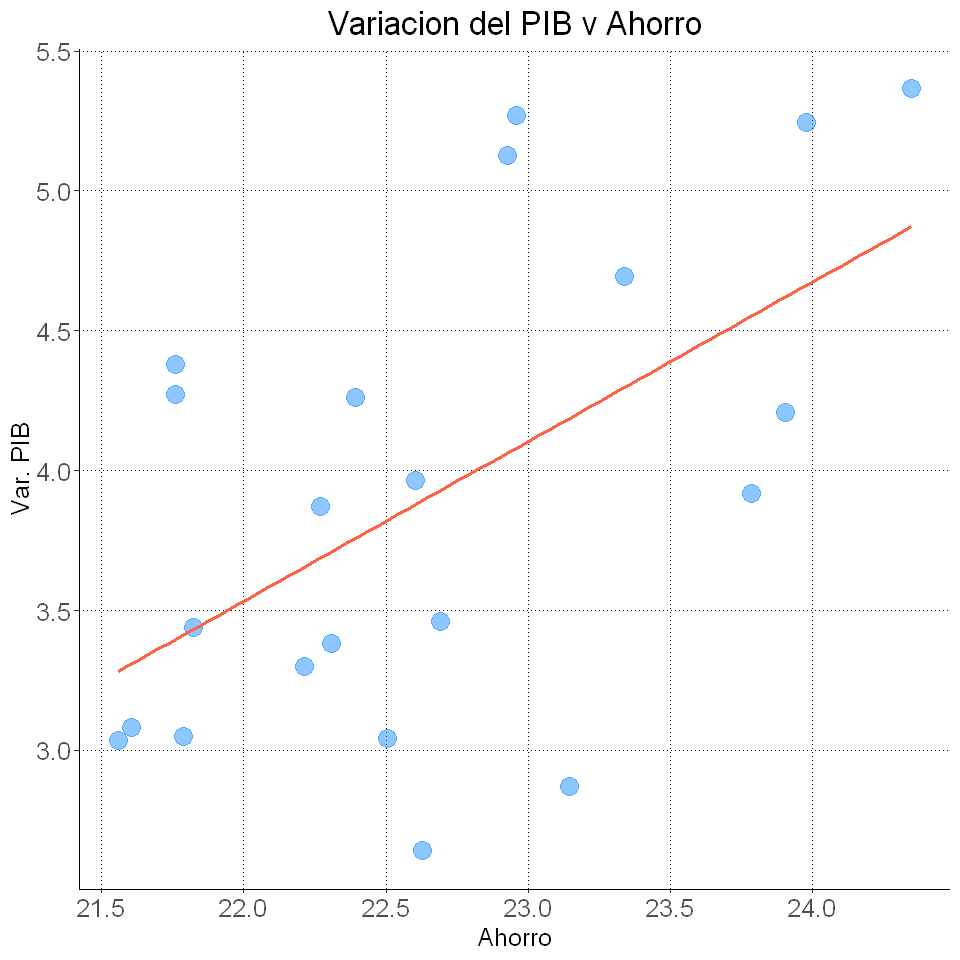

In [36]:
options(repr.plot.width = 8, repr.plot.height = 8)
ggplot(
    data = prom_anuales,
    mapping = aes(
        x = ahorro,
        y = var_pib
    )
) +
geom_point(
    color = "dodgerblue",
    alpha = 0.5,
    size = 5
) +
geom_smooth(
    formula = y ~ x,
    method = "lm",
    color = "tomato",
    se = FALSE
) +
labs(
    title = "Variacion del PIB v Ahorro",
    x = "Ahorro",
    y = "Var. PIB"
) +
theme_classic() +
theme(
    panel.grid.major = element_line(color = "black", linetype = "dotted"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15)
)

Visualiza ahora la relación existente entre pct_urbana y var_pib mediante una gráfica de dispersión.

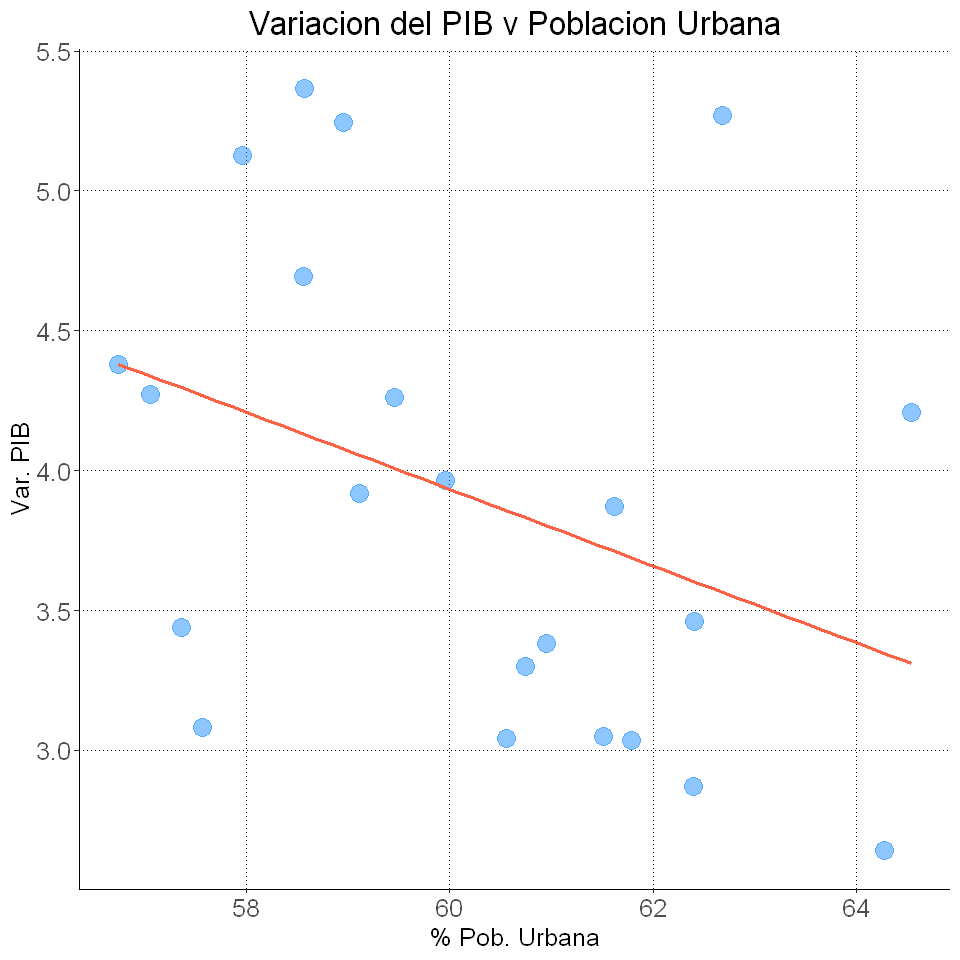

In [37]:
ggplot(
    data = prom_anuales,
    mapping = aes(
        x = pct_urbana,
        y = var_pib
    )
) +
geom_point(
    color = "dodgerblue",
    alpha = 0.5,
    size = 5
) +
geom_smooth(
    formula = y ~ x,
    method = "lm",
    color = "tomato",
    se = FALSE
) +
labs(
    title = "Variacion del PIB v Poblacion Urbana",
    x = "% Pob. Urbana",
    y = "Var. PIB"
) +
theme_classic() +
theme(
    panel.grid.major = element_line(color = "black", linetype = "dotted"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15)
)

**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | Si bien a nivel de cada país no se evidencia que el ningun indicador tiene una relación significativa con los cambios en el PIB (lo cual está aasociado al grado de volatilidad observado por las diversas condiciones y políticas socioeonómicas de cada estado), a nivel promedio se podría afirmar que un mayor ahorro de la población conlleva mejores niveles de crecimiento económico producto de una mayor capacidad financiera para la generación de capital y consumo. |
| 2 | En esta línea, en promedio se evidencia una relación negativa entre el porcentaje de población urbana y variación en el PIB, lo cual da cuenta posiblemente de mayores potenciales de desarrollo en estados con alta incidencia agrícola y extractiva. Lo anterior no sugiere que estados con estas características sean más desarrollados que su contraparte, sino que los cambios observados a nivel de PIB son más grandes en términos porcentuales. |

### ¿Qué tan probable es que un país tenga una recesión en un año cualquiera?

Crea una nueva columna en el dataset de forma que se evidencien los casos en los que han existido recesiones.

In [38]:
df_sin_atipicos <- df_sin_atipicos %>%
mutate(es_recesion = var_pib < 0)

df_sin_atipicos %>% sample_n(10)

country_code,country_name,year,var_pib,ahorro,var_pob,pct_urbana,es_recesion
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
DNK,Dinamarca,2002,0.4663456,25.258395,0.3194871,85.250,FALSE
PHL,Filipinas,2011,3.8582328,36.875071,1.7816588,45.522,FALSE
LBN,Libano,2011,0.8673399,2.700927,0.9811194,87.484,FALSE
NAM,Namibia,2011,5.0913381,14.768089,1.5629827,42.637,FALSE
LTU,Lituania,2014,3.5370099,23.084178,-0.8598273,67.108,FALSE
MKD,Macedonia del Norte,2003,2.2226017,15.712923,0.1270381,57.921,FALSE
MDG,Madagascar,2017,3.9333076,14.650535,2.5841649,36.522,FALSE
GHA,Ghana,2017,8.1288949,15.859632,2.2349454,55.407,FALSE
ITA,Italia,2004,1.4235942,20.776031,0.6471827,67.620,FALSE


Calcula en cuántos casos del dataset han existido recesiones y guarda este resultado en una variable llamada `casos_exitosos`.

In [39]:
casos_exitosos <- sum(df_sin_atipicos$es_recesion)

Guarda la totalidad de casos posibles en la variable `casos_totales`.

In [40]:
casos_totales <- nrow(df_sin_atipicos)

Calcula la probabilidad de que en un año cualquiera un país entre en recesión. Recuerda que una probabilidad se mide como la razón entre los casos de éxito (eventos en los que sucede algo que estamos queriendo medir) y los casos totales observados. Además, una probabilidad debe cumplir 3 condiciones:

1. Es positiva, es decir, todo evento *puede* suceder.
2. Es estrictamente menor o igual a 1, es decir, existen otros eventos *posibles*.
3. La suma de todas las probabilidades de eventos posibles en un experimento es igual a 1, es decir, alguno *debe* suceder. 

In [41]:
prob_recesion <- casos_exitosos / casos_totales
print(paste(
    "La probabilidad que un país entre en recesión en un año cualquiera es de: ",
    formatC(prob_recesion * 100, format = "f", digits = 1),
    "%.",
    sep = ""
))

[1] "La probabilidad que un país entre en recesión en un año cualquiera es de: 7.1%."


Vale que notes que esta probabilidad obtenida podría calcularse de forma directa con el siguiente código:

```r
prob_recesion <- mean(df_sin_atipicos$es_recesion)
```

Piensa el porqué esto funciona.

Encuentra el top 10 de países con una mayor probabilidad de recesión.

In [42]:
rec_por_pais <- df_sin_atipicos %>%
group_by(country_name) %>%
summarise(prob_recesion = mean(es_recesion)) %>%
ungroup() %>%
arrange(desc(prob_recesion)) %>%
slice_head(n = 10)

rec_por_pais

country_name,prob_recesion
<chr>,<dbl>
Libia,0.4615385
Argentina,0.3809524
Aruba,0.3333333
Brunei Darussalam,0.3181818
Haiti,0.2857143
Sudan,0.2500000
Bahamas,0.2380952
Croacia,0.2380952
Paraguay,0.2272727


Identifica igualmente el porcentaje de paises que han presentado recesiones en este periodo de tiempo.

In [43]:
# Contar paises con recesion
paises_con_recesion <- df_sin_atipicos %>%
filter(es_recesion) %>%
summarise(n_paises = n_distinct(country_name)) %>%
pull()

# Contar total de paises
paises_totales <- df_sin_atipicos %>%
summarise(n_paises = n_distinct(country_name)) %>%
pull()

# Calcular porcentaje
porc_paises <- paises_con_recesion / paises_totales
print(paste(
    "Porcentaje de paises con alguna recesion: ",
    formatC(porc_paises * 100, format = "f", digits = 1),
    "%",
    sep = ""
))

[1] "Porcentaje de paises con alguna recesion: 58.0%"


**CONCLUSIONES**

| # | Conclusiones |
| ---- | ---- |
| 1 | En promedio, un año malo en términos económicos para un país puede presentarse una vez por cada 12 años. De manera consecuente se pueden esperar ciclos de alrededor de 10 a 11 años de crecimiento sostenido en las economías nacionales, ante lo cual las políticas de desarrollo e inversión pública y privada deberían alinearse a esta realidad observada para así garantizar que las variaciones positivas en el PIB sean las máximas posibles en estos años. |
| 2 | Entre los 10 países con mayor probabilidad de recesión resaltan, aquellos en donde han existido situación graves en términos económicos, sociales o políticos. Por ejemplo en Libia existe una grave crisis humanitaria desde el año 2011, en Argentina se han presentado períodos de deterioro económico especialmente a principios de la década del 2000. Lo expusto ratifica lo mencionado en cuanto al impacto de factores externos en la variación del PIB. |
| 3 | Las recesiones en este siglo son un escenario bastante común, lo anterior queda evidenciado en el hecho que casi un 60% de los países las han tenido. Es recomendable por tanto, que el Banco Mundial amplíe su expectro de apoyo a países exigiendo como garantías el cumplimiento de políticas de desarrollo. |

### ¿Existen diferencias en el crecimiento de países de "bajo desarrollo" frente a países de "alto desarrollo"?

Escoge 10 países que consideres de bajo desarrollo (i.e Ecuador, Bolivia, Guatemala, etc.), y 10 que consideres de alto desarrollo (i.e Estados Unidos, Alemania, Japón, etc.). Filtra el dataset de forma que solamente conserves estos países y adiciona una nueva columna que distinga a los dos grupos.  

In [44]:
# Seleccionar paises de alto y bajo desarrollo
bajo_desarrollo <- c(
    "Ecuador", 
    "Bolivia", 
    "Guatemala", 
    "Madagascar", 
    "Nepal", 
    "Niger", 
    "Nicaragua", 
    "Burundi", 
    "Mali", 
    "Haiti"
)
alto_desarrollo <- c(
    "Estados Unidos", 
    "Alemania", 
    "Japon", 
    "Francia", 
    "Canada", 
    "Noruega", 
    "Australia", 
    "Singapur", 
    "Dinamarca", 
    "Suiza"
)

paises_seleccionados <- c(bajo_desarrollo, alto_desarrollo)

In [45]:
# Filtrar dataset con paises seleccionados y adicionar columna con tipologia de pais
df_filtrado <- df_sin_atipicos %>%
filter(country_name %in% paises_seleccionados) %>%
mutate(type = if_else(
    country_name %in% bajo_desarrollo,
    "Bajo",
    "Alto"
)) 

df_filtrado %>% count(type, country_name)

type,country_name,n
<chr>,<chr>,<int>
Alto,Alemania,22
Alto,Australia,22
Alto,Canada,22
Alto,Dinamarca,22
Alto,Estados Unidos,22
Alto,Francia,22
Alto,Japon,22
Alto,Noruega,22
Alto,Singapur,21


Estudia comparativamente la distribución de var_pib en los países de alto y bajo desarrollo.

In [46]:
# Generar un resumen estadistico por tipo de pais
res_estadistico <- df_filtrado %>%
group_by(type) %>%
summarise(
    count = n(),
    min = min(var_pib),
    q1 = quantile(var_pib, 0.25),
    med = median(var_pib),
    mean = mean(var_pib),
    q3 = quantile(var_pib, 0.75),
    max = max(var_pib),
    std = sd(var_pib),
    cv = std / mean
) %>%
ungroup()

res_estadistico

type,count,min,q1,med,mean,q3,max,std,cv
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Alto,219,-1.224289,1.169906,2.209543,2.39963,3.062261,9.939983,1.769222,0.7372896
Bajo,216,-3.900000,2.505858,4.096881,3.79771,5.212214,10.548945,2.468455,0.6499852


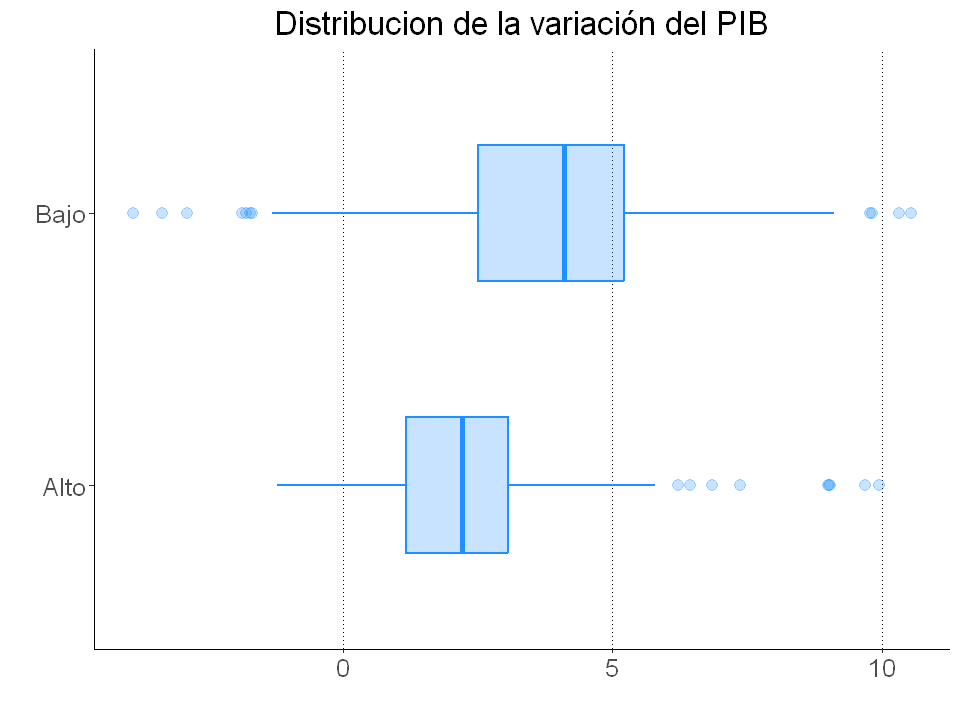

In [47]:
# Visualizar cajones por tipo
options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(
    data = df_filtrado,
    mapping = aes(
        x = var_pib,
        y = type
    )
) +
geom_boxplot(
    fill = "dodgerblue",
    alpha = 0.25,
    color = "dodgerblue",
    outlier.size = 3,
    linewidth = 0.75,
    width = 0.5
) +
labs(
    title = "Distribucion de la variación del PIB",
    x = "",
    y = ""
) +
theme_classic() +
theme(
    panel.grid.major.x = element_line(color = "black", linetype = "dotted"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15)
)

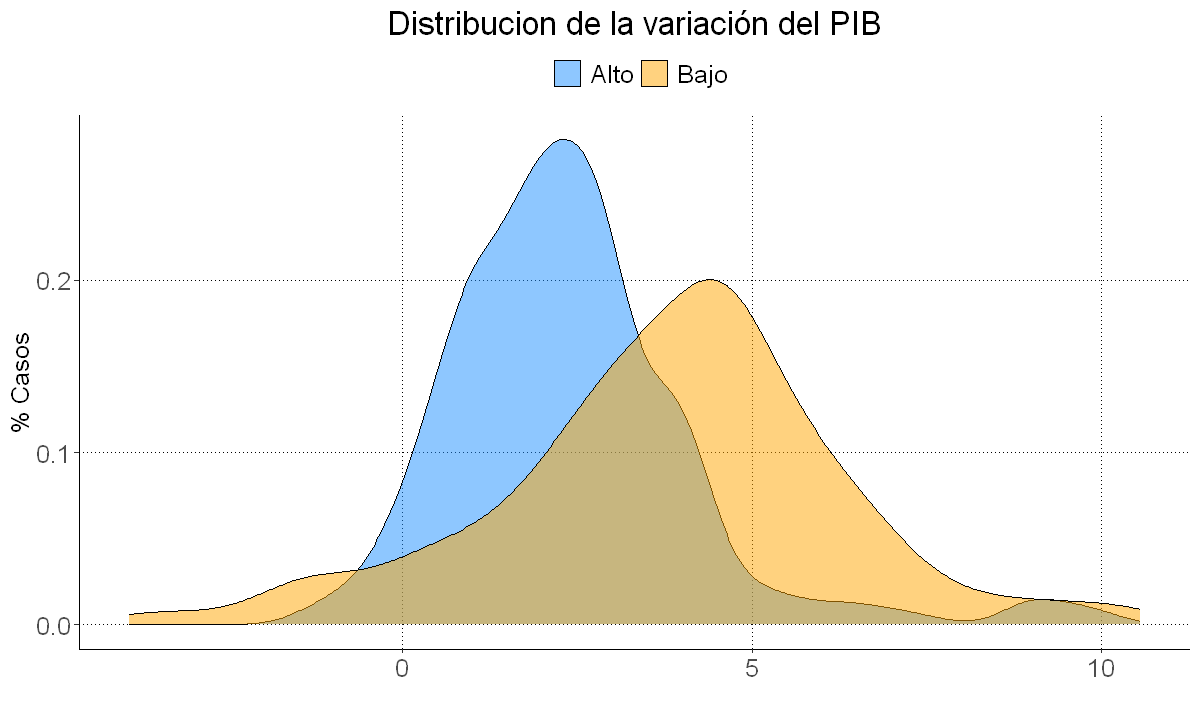

In [48]:
# Visualizar densidades por tipo
options(repr.plot.width = 10, repr.plot.height = 6)
ggplot(
    data = df_filtrado,
    mapping = aes(
        x = var_pib,
        fill = type,
    )
) +
scale_fill_manual(values = c("dodgerblue","orange")) +
geom_density(
    alpha = 0.5
) +
labs(
    title = "Distribucion de la variación del PIB",
    x = "",
    y = "% Casos",
    fill = ""
) +
theme_classic() +
theme(
    panel.grid.major = element_line(color = "black", linetype = "dotted"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15),
    legend.text = element_text(size = 15),
    legend.position = "top"
)

Los resultados aquí alcanzados parecerían indicar que en promedio la variación del PIB en países de bajo desarrollo es mayor a aquella de los países de alto desarrollo. 

¿Cómo podemos estar completamente seguros de esta afirmación? La respuesta radica en la **Inferencia estadística**, cuyas técnicas nos permiten verificar hipótesis de forma objetiva y robusta. Investiga acerca de esta temática con enfoque en conceptos como pruebas de hipótesis o intervalos de confianza, que en todo caso veremos más adelante.

**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | Los países de bajo desarrollo tenderían a crecer porcentaulmente más que los países más desarrollados. Esto en principio podría resultar contraintuitivo pero se explica por el hecho que incrementar 1 punto porcentual de una base menor es "más sencillo" que hacerlo de una base mayor. Aquí un ejemplo puramente ilustrativo: Sea USD100 M el PIB de un país de bajo desarrollo en un año cualquiera, y USD1,000 M el de un pais de alto desarrollo. Incrementar 1% para el primer caso implica una variación absoluta de apenas USD 1 millón, mientras que para el segundo sería USD 10 millones. ¡Mucho más! |

Como has podido evidenciar, saber estadística te ayudará mucho en tu camino como analista o científico de datos. Te recomiendo por tanto que escuches este playlist sobre [Fundamentos de Estadística](https://www.youtube.com/playlist?list=PLblh5JKOoLUK0FLuzwntyYI10UQFUhsY9) creado por el canal StatQuest de Josh Starmer.